## 1) Problem setup
We solve on $D=(0,1)$ with homogeneous Dirichlet boundary conditions:
$$-\frac{d}{dx}\left(a(x;r)\,u'(x)\right) = f(x), \quad u(0)=u(1)=0.$$
The coefficient is an **inclusion** centered at $x_0=0.5$ with radius $r$:
$$a(x;r)=\begin{cases} a_{\text{in}}, & |x-x_0|\le r\\ a_{\text{out}}, & \text{else.}\end{cases}$$
We observe $u$ at a few sensor locations and infer $r$.

In [14]:
from numpy.polynomial.legendre import leggauss
from scipy.stats import linregress
import numpy as np
import matplotlib
import matplotlib.pyplot as plt 

# ==========================================
# 1. PROBLEM SETUP (The Inclusion)
# ==========================================

def a0(x, beta):
    """
    Discontinuous coefficient a(x).
    beta = (x_star, r) -> Center and radius of inclusion.
    Returns 2.0 inside inclusion, 1.0 outside.
    """
    x_star, r_val = beta
    x = np.asarray(x)
    # Using 5.0 for a strong contrast (stiffer material)
    condition = (x >= (x_star - r_val)) & (x <= (x_star + r_val))
    return np.where(condition, 5, 1.0)

def f(x, beta):
    """Source term f(x) = 1.0"""
    x = np.asarray(x)
    return np.ones_like(x)

# ==========================================
# 2. QUADRATURE & FEM UTILS
# ==========================================

def get_discont_points(x_left, x_right, beta):
    """Finds discontinuity points within an element [x_left, x_right]."""
    x_star, r_val = beta
    pts = []
    p1 = x_star - r_val
    p2 = x_star + r_val
    
    if x_left < p1 < x_right:
        pts.append(p1)
    if x_left < p2 < x_right:
        pts.append(p2)
    return pts

def GL(x_left, x_right, func):
    """Standard Gauss-Legendre Quadrature (5 points)."""
    # 5-point quadrature is sufficient for this degree
    xi, ci = leggauss(5)
    # Map from [-1, 1] to [x_left, x_right]
    x_mapped = 0.5 * ((x_right - x_left) * xi + (x_right + x_left))
    integrand_values = func(x_mapped)
    return 0.5 * (x_right - x_left) * np.dot(ci, integrand_values)

def piecewise_GL(integrand, x_left, x_right, discont_points=None):
    """
    Key Helper: Splits integration if a discontinuity exists in the element.
    This prevents O(h^1/2) error pollution.
    """
    if discont_points is None or len(discont_points) == 0:
        return GL(x_left, x_right, integrand)
    
    # Filter points actually inside interval
    splits = sorted([p for p in discont_points if x_left < p < x_right])
    pts = [x_left] + splits + [x_right]
    
    total = 0.0
    for i in range(len(pts) - 1):
        total += GL(pts[i], pts[i+1], integrand)
    return total

def phi_i(i, x, mesh):
    """1D Hat Basis Function for node i."""
    x = np.asarray(x)
    N = len(mesh) - 1
    
    # Left boundary
    if i == 0:
        cond = (x >= mesh[0]) & (x <= mesh[1])
        return np.where(cond, (mesh[1] - x) / (mesh[1] - mesh[0]), 0.0)
    # Right boundary
    elif i == N:
        cond = (x >= mesh[N-1]) & (x <= mesh[N])
        return np.where(cond, (x - mesh[N-1]) / (mesh[N] - mesh[N-1]), 0.0)
    # Interior nodes
    else:
        left_cond = (x >= mesh[i-1]) & (x <= mesh[i])
        right_cond = (x > mesh[i]) & (x <= mesh[i+1])
        left_val = (x - mesh[i-1]) / (mesh[i] - mesh[i-1])
        right_val = (mesh[i+1] - x) / (mesh[i+1] - mesh[i])
        return np.where(left_cond, left_val, np.where(right_cond, right_val, 0.0))

def dphi_i_slope(i, k, mesh):
    """Returns slope of phi_i on element k (constant)."""
    dx = mesh[k+1] - mesh[k]
    if i == k: return -1.0/dx      # Left node of element -> slope down
    elif i == k+1: return 1.0/dx   # Right node of element -> slope up
    return 0.0

# ==========================================
# 3. ASSEMBLY & SOLVER
# ==========================================

def assemble_system(mesh, beta):
    N = len(mesh)
    S = np.zeros((N, N))
    F = np.zeros(N)
    
    # --- Matrix Assembly ---
    # We iterate over elements to build the matrix
    # (Simplified element-wise assembly for 1D)
    for k in range(N - 1): # Loop over elements
        x_L, x_R = mesh[k], mesh[k+1]
        disconts = get_discont_points(x_L, x_R, beta)
        
        # Local Stiffness terms (gradients)
        # On element k, only phi_k and phi_{k+1} are non-zero
        for i_local in [k, k+1]:
            for j_local in [k, k+1]:
                def integrand_S(x):
                    # a(x) * grad(phi_i) * grad(phi_j)
                    s_i = dphi_i_slope(i_local, k, mesh)
                    s_j = dphi_i_slope(j_local, k, mesh)
                    return a0(x, beta) * s_i * s_j
                
                val = piecewise_GL(integrand_S, x_L, x_R, disconts)
                S[i_local, j_local] += val

        # --- Force Vector Assembly ---
        for i_local in [k, k+1]:
            def integrand_F(x):
                return f(x, beta) * phi_i(i_local, x, mesh)
            F[i_local] += piecewise_GL(integrand_F, x_L, x_R, disconts)
            
    # Apply Dirichlet BCs: u(0)=0, u(1)=0
    # We slice out the inner nodes (1 to N-2)
    S_inner = S[1:-1, 1:-1]
    F_inner = F[1:-1]
    
    return S_inner, F_inner

def solve_fem(mesh, beta):
    S_in, F_in = assemble_system(mesh, beta)
    c_inner = np.linalg.solve(S_in, F_in)
    # Pad with zeros for boundary conditions
    return np.concatenate(([0.0], c_inner, [0.0]))

# ==========================================
# 4. ERROR ESTIMATOR & REFINEMENT
# ==========================================

def compute_element_errors(mesh, u_sol, beta):
    """Computes residual-based error estimator for each element."""
    errors = []
    for k in range(len(mesh)-1):
        x_L, x_R = mesh[k], mesh[k+1]
        h = x_R - x_L
        
        # Residual Term: h^2 * ||f + div(a grad u)||^2
        # In 1D with linear elements, div(a grad u) is zero inside element 
        # (if a is const), but non-zero if a jumps inside.
        # Simplified: We use the approximation from thesis eq 4.3.2
        # r_T = f (since laplacian of linear u is 0)
        
        def resid_sq(x): return f(x, beta)**2
        disconts = get_discont_points(x_L, x_R, beta)
        norm_r = piecewise_GL(resid_sq, x_L, x_R, disconts)
        
        # Jump Term: Flux jump at nodes. 
        # (Simplified for demo: We focus on residual domination in 1D)
        eta_sq = (h**2) * norm_r 
        errors.append(eta_sq)
        
    return np.array(errors)

def dorfler_marking(errors, theta=0.5):
    """Selects elements that contribute top theta% of total error."""
    total_error = np.sum(errors)
    # Sort indices by error descending
    sorted_indices = np.argsort(-errors)
    cum_sum = np.cumsum(errors[sorted_indices])
    
    # Find cutoff
    cutoff = np.searchsorted(cum_sum, theta * total_error)
    return sorted_indices[:cutoff+1]

def refine_mesh(mesh, marked_indices):
    """Bisects marked elements."""
    mesh = np.array(mesh)
    new_nodes = []
    
    # Indices are element indices. Element k is between node k and k+1
    for k in marked_indices:
        midpoint = 0.5 * (mesh[k] + mesh[k+1])
        new_nodes.append(midpoint)
        
    # Combine and sort
    combined = np.concatenate((mesh, new_nodes))
    return np.unique(np.sort(combined))

    
def generate_afem_benchmark(beta, max_dof, theta):
    """Generates a high-resolution reference solution using AFEM."""
    print(f"Generating AFEM Benchmark (Target DoF > {max_dof})...")
    mesh = np.linspace(0, 1, 5)
    
    while len(mesh) < max_dof:
        u = solve_fem(mesh, beta)
        errors = compute_element_errors(mesh, u, beta)
        marked = dorfler_marking(errors, theta)
        if len(marked) == 0: break
        mesh = refine_mesh(mesh, marked)
    
    # One final solve on the fine mesh
    u_ref = solve_fem(mesh, beta)
    print(f"Benchmark Generated: {len(mesh)} nodes.")
    return mesh, u_ref

In [15]:
def get_u_value(x, mesh, u_vals):
    """Interpolate u at x given a mesh and nodal values."""
    idx = np.searchsorted(mesh, x) - 1
    if idx < 0: idx = 0
    if idx >= len(mesh)-1: idx = len(mesh)-2
    
    xL, xR = mesh[idx], mesh[idx+1]
    uL, uR = u_vals[idx], u_vals[idx+1]
    # Linear interpolation
    return uL + (uR - uL) * (x - xL) / (xR - xL)

def get_u_grad(x, mesh, u_vals):
    """Get gradient at x (constant on elements)."""
    idx = np.searchsorted(mesh, x) - 1
    if idx < 0: idx = 0
    if idx >= len(mesh)-1: idx = len(mesh)-2
    
    xL, xR = mesh[idx], mesh[idx+1]
    return (u_vals[idx+1] - u_vals[idx]) / (xR - xL)

def compute_l2_error(mesh, u, mesh_ref, u_ref):
    """
    L2 Error = sqrt( Integral (u - u_ref)^2 )
    Integrates over the FINE REFERENCE mesh elements for accuracy.
    """
    err_sq = 0.0
    for k in range(len(mesh_ref)-1):
        xL, xR = mesh_ref[k], mesh_ref[k+1]
        
        # On this fine interval, u_ref is linear.
        # u is also linear (because fine interval is subset of coarse interval).
        
        # Get local linear coeffs for u_ref
        grad_ref = (u_ref[k+1] - u_ref[k]) / (xR - xL)
        c_ref = u_ref[k] - grad_ref * xL # intercept relative to xL logic
        
        # Get local linear coeffs for u (from coarse mesh)
        # Find which coarse element contains midpoint
        mid = 0.5 * (xL + xR)
        idx = np.searchsorted(mesh, mid) - 1
        grad_u = (u[idx+1] - u[idx]) / (mesh[idx+1] - mesh[idx])
        c_u = u[idx] + grad_u * (xL - mesh[idx]) # Value at xL
        
        # We integrate ( (c_u + grad_u*dx) - (u_ref_val + grad_ref*dx) )^2
        # It's a polynomial of degree 2, exact with GL(3).
        def integrand(x):
            val_u = get_u_value(x, mesh, u)
            val_ref = get_u_value(x, mesh_ref, u_ref)
            return (val_u - val_ref)**2
            
        err_sq += GL(xL, xR, integrand)
        
    return np.sqrt(err_sq)

def compute_energy_error_sq(mesh, u, mesh_ref, u_ref, beta):
    """
    Squared Energy Error = Integral ( a(x) * (grad_u - grad_ref)^2 )
    """
    err_sq = 0.0
    for k in range(len(mesh_ref)-1):
        xL, xR = mesh_ref[k], mesh_ref[k+1]
        mid = 0.5 * (xL + xR)
        
        # Gradients are constant on elements
        grad_ref = (u_ref[k+1] - u_ref[k]) / (xR - xL)
        grad_u = get_u_grad(mid, mesh, u)
        
        def integrand(x):
            return a0(x, beta) * (grad_u - grad_ref)**2
        
        # Split integration if a(x) jumps within reference element (unlikely if fine)
        pts = sorted([xL] + get_discont_points(xL, xR, beta) + [xR])
        for m in range(len(pts)-1):
            err_sq += GL(pts[m], pts[m+1], integrand)
            
    return err_sq

# ==========================================
# 5. MAIN EXECUTION
# ==========================================

def run_demo(beta_real, theta, max_iter):
    # 1. Generate High-Res AFEM Benchmark
    mesh_ref, u_ref = generate_afem_benchmark(beta_real, max_dof=10240, theta = theta)
    
    # 2. Run AFEM Study
    print("\nRunning AFEM Study...")
    mesh_afem = np.linspace(0, 1, 5)
    afem_dofs, afem_l2, afem_Esq = [], [], []
    
    for _ in range(max_iter): # Run 15 adaptive steps
        u_afem = solve_fem(mesh_afem, beta_real)
        
        # Compute Errors
        l2 = compute_l2_error(mesh_afem, u_afem, mesh_ref, u_ref)
        esq = compute_energy_error_sq(mesh_afem, u_afem, mesh_ref, u_ref, beta_real)
        
        afem_dofs.append(len(mesh_afem))
        afem_l2.append(l2)
        afem_Esq.append(esq)
        
        # Refine
        est = compute_element_errors(mesh_afem, u_afem, beta_real)
        marked = dorfler_marking(est, theta)
        mesh_afem = refine_mesh(mesh_afem, marked)
        
    # 3. Run Uniform Study
    print("Running Uniform Study...")
    unif_dofs, unif_l2, unif_Esq = [], [], []
    for n in [320, 640, 1280, 2560, 5120]:
        mesh_u = np.linspace(0, 1, n+1)
        u_u = solve_fem(mesh_u, beta_real)
        
        l2 = compute_l2_error(mesh_u, u_u, mesh_ref, u_ref)
        esq = compute_energy_error_sq(mesh_u, u_u, mesh_ref, u_ref, beta_real)
        
        unif_dofs.append(len(mesh_u))
        unif_l2.append(l2)
        unif_Esq.append(esq)

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Plot 1: L2 Error ---
    s_afem, _, _, _, _ = linregress(np.log(afem_dofs[-5:]), np.log(afem_l2[-5:]))
    s_unif, _, _, _, _ = linregress(np.log(unif_dofs[-4:]), np.log(unif_l2[-4:]))
    
    ax1.loglog(unif_dofs, unif_l2, 'g--o', label=f'Uniform (Slope={s_unif:.2f})')
    ax1.loglog(afem_dofs, afem_l2, 'b-o', label=f'AFEM (Slope={s_afem:.2f})')
    
    # Reference lines
    ref = np.array(afem_dofs)
    ax1.loglog(ref, 0.1*ref**(-2.0), 'k--', label='O(N^-2)', alpha=0.5)
    
    ax1.set_xlabel('Degrees of Freedom (N)')
    ax1.set_ylabel('L2 Error ||u - u_ref||')
    ax1.set_title('L2 Norm Convergence')
    ax1.legend()
    ax1.grid(True, which="both", linestyle='--', alpha=0.4)
    
    # --- Plot 2: Squared Energy Error ---
    s_afem_E, _, _, _, _ = linregress(np.log(afem_dofs[-5:]), np.log(afem_Esq[-5:]))
    s_unif_E, _, _, _, _ = linregress(np.log(unif_dofs[-4:]), np.log(unif_Esq[-4:]))
    
    ax2.loglog(unif_dofs, unif_Esq, 'g--o', label=f'Uniform (Slope={s_unif_E:.2f})')
    ax2.loglog(afem_dofs, afem_Esq, 'b-o', label=f'AFEM (Slope={s_afem_E:.2f})')
    
    ax2.loglog(ref, 1.0*ref**(-1.0), 'k:', label='O(N^-1)', alpha=0.5)
    ax2.loglog(ref, 1.0*ref**(-2.0), 'k--', label='O(N^-2)', alpha=0.5)
    
    ax2.set_xlabel('Degrees of Freedom (N)')
    ax2.set_ylabel('Squared Energy Error ||u - u_ref||_E^2')
    ax2.set_title('Squared Energy Norm Convergence')
    ax2.legend()
    ax2.grid(True, which="both", linestyle='--', alpha=0.4)
    
    plt.show()

Generating AFEM Benchmark (Target DoF > 2000)...
Benchmark Generated: 2248 nodes.


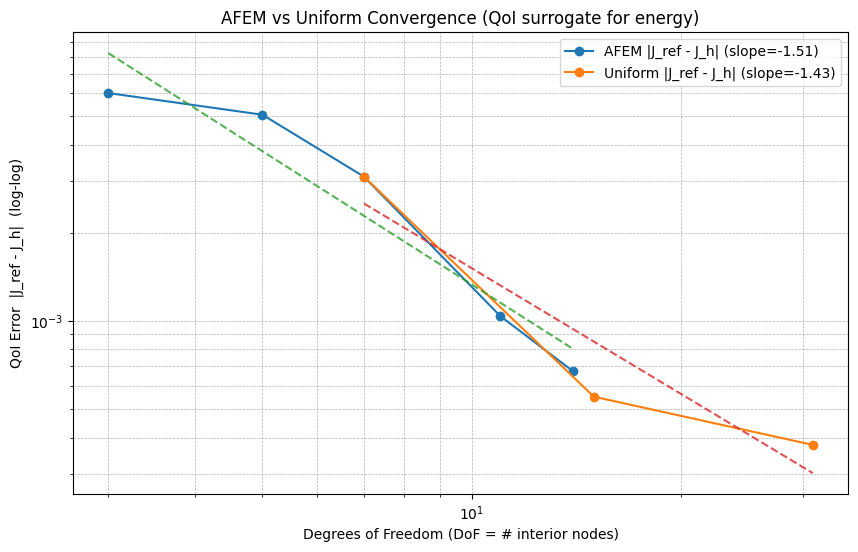

J_ref = 0.041777839647498455
AFEM ddof: [ 3.  5.  7. 11. 14.]
AFEM err : [0.00600762 0.0050664  0.00311327 0.00103967 0.00067346]
UNI  ddof: [ 7. 15. 31.]
UNI  err : [0.00311327 0.00055139 0.0003774 ]


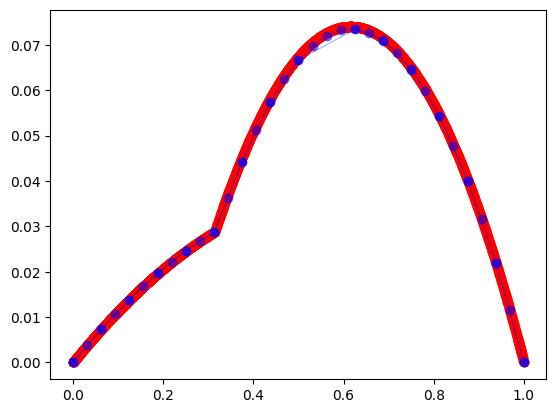

In [ ]:

def qoi_J(mesh, u_full, beta):
    """
    J(u_h) = ∫_0^1 f(x,beta) u_h(x) dx
    In FEM: J ≈ u^T F. Since u(0)=u(1)=0, we can use inner parts:
      J = u_inner^T F_inner
    where F_inner is from assemble_system(mesh,beta).
    """
    _, F_inner = assemble_system(mesh, beta)      # size: (N-2,)
    u_inner = u_full[1:-1]                        # size: (N-2,)
    return float(np.dot(u_inner, F_inner))

def afem_history(beta, theta=0.5, max_iter=30):
    """
    Collect (meshes, sols, ddof_list, J_list) for AFEM iterations.
    """
    meshes, sols, ddofs, J_list = [], [], [], []
    mesh = np.linspace(0, 1, 5)

    for it in range(max_iter):
        u = solve_fem(mesh, beta)

        meshes.append(mesh.copy())
        sols.append(u.copy())
        ddofs.append(len(mesh) - 2)

        J_list.append(qoi_J(mesh, u, beta))

        # mark & refine
        errors = compute_element_errors(mesh, u, beta)
        marked = dorfler_marking(errors, theta)
        if len(marked) == 0:
            break
        mesh_new = refine_mesh(mesh, marked)
        if len(mesh_new) == len(mesh):
            break
        mesh = mesh_new

    return meshes, sols, np.array(ddofs, dtype=float), np.array(J_list, dtype=float)

def uniform_history(beta, l_min=3, l_max=14):
    """
    Collect (ddof_list, J_list) for uniform refinement meshes:
      N_nodes = 2^l + 1
      ddof = N_nodes - 2
    """
    ddofs, J_list, uni_meshes, uni_sols = [], [], [], []
    for l in range(l_min, l_max + 1):
        mesh = np.linspace(0.0, 1.0, 2**l + 1)
        u = solve_fem(mesh, beta)
        ddofs.append(len(mesh) - 2)
        J_list.append(qoi_J(mesh, u, beta))
        uni_meshes.append(mesh)
        uni_sols.append(u)
    return np.array(ddofs, dtype=float), np.array(J_list, dtype=float), uni_meshes, uni_sols

def fit_slope(ddof, err, tail_k=6):
    """
    Fit slope on last tail_k points in log-log scale.
    Uses abs(err) to avoid log issues.
    """
    ddof = np.asarray(ddof)
    err = np.asarray(err)
    y = np.abs(err)

    # avoid log(0)
    eps = 1e-300
    y = np.maximum(y, eps)

    if len(ddof) < 2:
        return np.nan, np.nan

    k = min(tail_k, len(ddof))
    x_fit = np.log(ddof[-k:])
    y_fit = np.log(y[-k:])
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    return slope, intercept

def plot_qoi_convergence(beta, theta=0.5, max_iter=25, benchmark_dof=4000,
                         l_min=3, l_max=14, tail_k=6):
    """
    1) Build a fine AFEM benchmark u_ref (truth)
    2) Run AFEM history + Uniform history
    3) Plot |J_ref - J_h| vs DoF (log-log) and fit slopes
    """
    # --- benchmark truth (fine AFEM) ---
    mesh_ref, u_ref = generate_afem_benchmark(beta, max_dof=benchmark_dof, theta=theta)
    J_ref = qoi_J(mesh_ref, u_ref, beta)

    # --- AFEM history (coarse->refined) ---
    afem_meshes, afem_sols, afem_ddof, afem_J = afem_history(beta, theta=theta, max_iter=max_iter)
    afem_err = J_ref - afem_J

    # --- uniform history ---
    uni_ddof, uni_J, uni_meshes, uni_sols = uniform_history(beta, l_min=l_min, l_max=l_max)
    uni_err = J_ref - uni_J

    # --- fit slopes on tail (optional but nice for interview) ---
    afem_slope, afem_b = fit_slope(afem_ddof, afem_err, tail_k=tail_k)
    uni_slope,  uni_b  = fit_slope(uni_ddof,  uni_err,  tail_k=tail_k)

    # build fitted lines for plotting
    def fit_line(ddof, slope, intercept):
        return np.exp(intercept) * np.power(ddof, slope)

    afem_fit = fit_line(afem_ddof, afem_slope, afem_b) if np.isfinite(afem_slope) else None
    uni_fit  = fit_line(uni_ddof,  uni_slope,  uni_b)  if np.isfinite(uni_slope)  else None

    # --- plot ---
    plt.figure(figsize=(10, 6))
    plt.loglog(afem_ddof, np.abs(afem_err), 'o-', label=f'AFEM |J_ref - J_h| (slope={afem_slope:.2f})')
    plt.loglog(uni_ddof,  np.abs(uni_err),  'o-', label=f'Uniform |J_ref - J_h| (slope={uni_slope:.2f})')

    if afem_fit is not None:
        plt.loglog(afem_ddof, np.abs(afem_fit), '--', alpha=0.8)
    if uni_fit is not None:
        plt.loglog(uni_ddof,  np.abs(uni_fit),  '--', alpha=0.8)

    plt.xlabel('Degrees of Freedom (DoF = # interior nodes)')
    plt.ylabel('QoI Error  |J_ref - J_h|  (log-log)')
    plt.title('AFEM vs Uniform Convergence (QoI surrogate for energy)')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

    # print quick debug table
    print("J_ref =", J_ref)
    print("AFEM ddof:", afem_ddof)
    print("AFEM err :", afem_err)
    print("UNI  ddof:", uni_ddof)
    print("UNI  err :", uni_err)

    plt.figure() 
    plt.plot(mesh_ref, u_ref, "ro-", label = "Exact Ref", linewidth = 1, alpha = 1, markersize = 2)
    plt.plot(afem_meshes[-1], afem_sols[-1], "bo-", label="AFEM Solver", linewidth = 0.5, alpha = 0.5, markersize = 1)
    plt.plot(uni_meshes[-1], uni_sols[-1], "bo-", label = "Uniform Solver", linewidth = 0.5, alpha=0.5, markersize = 1)
    plt.show()

# -----------------------
# RUN (your usual knobs)
# -----------------------
beta = (0.0, 0.3141452)     # your one-sided inclusion demo
theta = 0.5
plot_qoi_convergence(beta, theta=theta, max_iter=20, benchmark_dof = 4096, l_min=3, l_max=10, tail_k=6)
